In [69]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Lasso, LassoCV

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [41]:
df = pd.read_csv('../data/processed/Cleaned_SCF_2022.csv', index_col=0)
df.shape

(4595, 12)

In [42]:
df.head()

,LOG_RETQLIQ,EDUC,HHOUSES,EMERGSAV,FINLIT,AGE,LOG_EQUITY,LOG_FIN,LOG_LIQ,LOG_INCOME,LOG_DEBT,LOG_STOCKS
0,12.409018,9,1,1,1,70,10.799596,12.461106,9.480444,10.566323,12.180760,0.000000
5,11.512935,12,1,1,3,46,10.308986,11.852970,10.609082,12.323103,13.159083,0.000000
10,13.036808,14,1,1,3,68,17.917856,17.918036,9.295692,13.006586,16.682273,17.904508
15,14.220309,12,0,1,3,74,14.360158,14.587007,12.007628,11.934327,0.000000,0.000000
20,0.000000,8,0,0,0,19,0.000000,7.003974,7.003974,10.936822,9.305741,0.000000


In [43]:
df.columns

Index(['LOG_RETQLIQ', 'EDUC', 'HHOUSES', 'EMERGSAV', 'FINLIT', 'AGE',
       'LOG_EQUITY', 'LOG_FIN', 'LOG_LIQ', 'LOG_INCOME', 'LOG_DEBT',
       'LOG_STOCKS'],
      dtype='str')

## Baseline Model

In [44]:
features = [
    # financial
    'LOG_EQUITY',
    'LOG_FIN',
    'LOG_LIQ',
    'LOG_INCOME',
    'LOG_DEBT',
    'LOG_STOCKS',
    # socioeconomic 
    'EDUC',
    'FINLIT',
    'AGE'
]

target = 'LOG_RETQLIQ'

In [45]:
X = df[features]
y = df[target]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3676, 9), (919, 9), (3676,), (919,))

In [48]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
y_pred = lr.predict(X_test)

In [50]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression")
print("R²:", r2)
print("RMSE:", rmse)

Baseline Linear Regression
R²: 0.7393707136905345
RMSE: 3.1480343709585057


In [51]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipeline.fit(X_train, y_train)
coefs = pipeline.named_steps['lr'].coef_.ravel()
coefficients = pd.Series(coefs, index=X.columns).sort_values(ascending=False)
coefficients

LOG_EQUITY    4.589697
LOG_FIN       2.108803
FINLIT        0.133680
LOG_DEBT      0.114301
EDUC          0.112848
LOG_INCOME   -0.030396
AGE          -0.290460
LOG_STOCKS   -0.889710
LOG_LIQ      -0.977985
dtype: float64

### Lasso  

In [52]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, random_state=42))
])

In [53]:
lasso_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [54]:
y_pred_lasso = lasso_pipeline.predict(X_test)

In [55]:
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression")
print("R²:", r2_lasso)
print("RMSE:", rmse_lasso)

Lasso Regression
R²: 0.73906223320988
RMSE: 3.1498968246935743


In [56]:
coefs = lasso_pipeline.named_steps['lasso'].coef_

lasso_coefficients = pd.Series(coefs, index=X.columns).sort_values(ascending=False)
print(lasso_coefficients)

LOG_EQUITY    4.599468
LOG_FIN       1.981168
FINLIT        0.126167
LOG_DEBT      0.110859
EDUC          0.105869
LOG_INCOME   -0.007373
AGE          -0.273812
LOG_STOCKS   -0.869572
LOG_LIQ      -0.882541
dtype: float64


In [57]:
lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42))
])

lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.named_steps['lasso'].alpha_
print("Best alpha:", best_alpha)

Best alpha: 0.005206728794340573


### Simplify Model

In [58]:
reduced_features = [
    'LOG_EQUITY',
    'LOG_FIN',
    'LOG_LIQ',
    'LOG_DEBT',
    'LOG_STOCKS',
    'EDUC',
    'FINLIT'
]

X_reduced = df[reduced_features]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

lr_reduced = LinearRegression()
lr_reduced.fit(X_train_r, y_train_r)

y_pred_r = lr_reduced.predict(X_test_r)

print("Reduced Model")
print("R²:", r2_score(y_test_r, y_pred_r))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))

Reduced Model
R²: 0.7382215919735767
RMSE: 3.1549666234544915


## Classification

In [37]:
median_salary_2022 = 55_058
threshold_65 = median_salary_2022 * 10 

In [59]:
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,70,100])

In [61]:
# Binary classification target
# 1 = above median retirement liquidity
# 0 = at or below median retirement liquidity

ready_threshold = df['LOG_RETQLIQ'].median()

df['RET_READY'] = (df['LOG_RETQLIQ'] > ready_threshold).astype(int)

df['RET_READY'].value_counts(normalize=True)

RET_READY
0    0.500326
1    0.499674
Name: proportion, dtype: float64

In [62]:
classification_features = [
    'LOG_EQUITY',
    'LOG_FIN',
    'LOG_LIQ',
    'LOG_DEBT',
    'LOG_STOCKS',
    'EDUC',
    'FINLIT',
    'AGE'
]

X_class = df[classification_features]
y_class = df['RET_READY']

In [63]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

X_train_c.shape, X_test_c.shape, y_train_c.shape, y_test_c.shape

((3676, 8), (919, 8), (3676,), (919,))

Logistic Regression Classifier

In [64]:
log_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

log_clf.fit(X_train_c, y_train_c)

y_pred_log = log_clf.predict(X_test_c)

In [65]:
print("Logistic Regression Classification Model")
print("Accuracy:", accuracy_score(y_test_c, y_pred_log))
print("Precision:", precision_score(y_test_c, y_pred_log))
print("Recall:", recall_score(y_test_c, y_pred_log))
print("F1 Score:", f1_score(y_test_c, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_log))

Logistic Regression Classification Model
Accuracy: 0.8955386289445049
Precision: 0.8837209302325582
Recall: 0.9106753812636166
F1 Score: 0.8969957081545065

Confusion Matrix:
[[405  55]
 [ 41 418]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       460
           1       0.88      0.91      0.90       459

    accuracy                           0.90       919
   macro avg       0.90      0.90      0.90       919
weighted avg       0.90      0.90      0.90       919



lr coefficients

In [66]:
log_coefs = log_clf.named_steps['logreg'].coef_.ravel()

log_coefficients = pd.Series(
    log_coefs,
    index=X_class.columns
).sort_values(ascending=False)

log_coefficients

LOG_FIN       2.904341
LOG_EQUITY    1.768751
FINLIT        0.230913
LOG_DEBT      0.176418
EDUC          0.017284
AGE          -0.173473
LOG_STOCKS   -0.752295
LOG_LIQ      -0.768619
dtype: float64

Random Forest Classifier

In [67]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

rf_clf.fit(X_train_c, y_train_c)

y_pred_rf = rf_clf.predict(X_test_c)

Eval Random Forest Classifier

In [68]:
print("Random Forest Classification Model")
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print("Precision:", precision_score(y_test_c, y_pred_rf))
print("Recall:", recall_score(y_test_c, y_pred_rf))
print("F1 Score:", f1_score(y_test_c, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_rf))

Random Forest Classification Model
Accuracy: 0.9216539717083787
Precision: 0.8909090909090909
Recall: 0.9607843137254902
F1 Score: 0.9245283018867925

Confusion Matrix:
[[406  54]
 [ 18 441]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       460
           1       0.89      0.96      0.92       459

    accuracy                           0.92       919
   macro avg       0.92      0.92      0.92       919
weighted avg       0.92      0.92      0.92       919



AUC / ROC

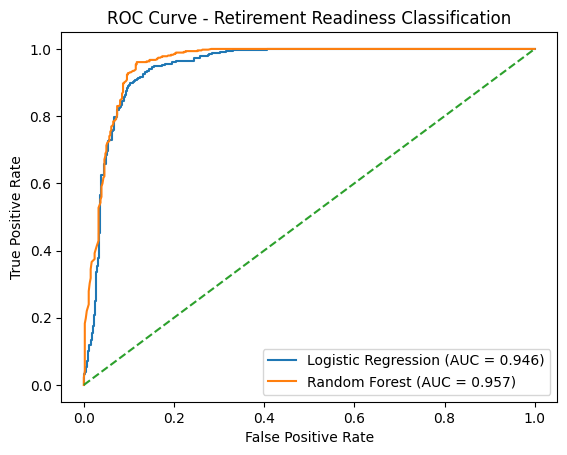

In [70]:
y_prob_log = log_clf.predict_proba(X_test_c)[:, 1]
y_prob_rf = rf_clf.predict_proba(X_test_c)[:, 1]

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test_c, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test_c, y_prob_rf)

# AUC scores
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure()
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Retirement Readiness Classification')
plt.legend()
plt.show()

Feature importance

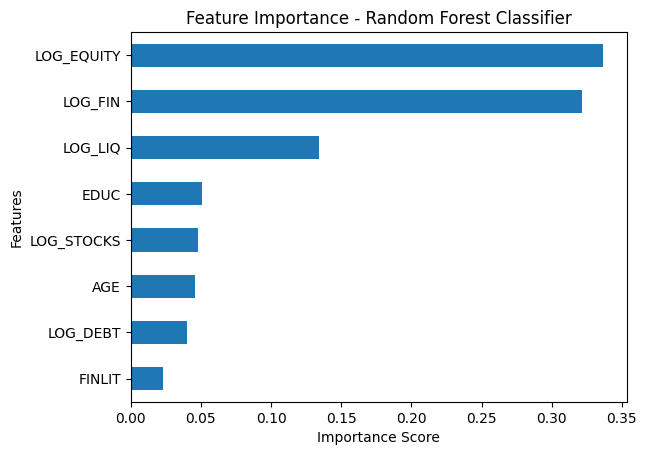

In [71]:
importance = pd.Series(
    rf_clf.feature_importances_,
    index=X_class.columns
).sort_values(ascending=True)

plt.figure()
importance.plot(kind='barh')

plt.title('Feature Importance - Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

Financial Readiness by Age group

In [73]:
df_results = X_test_c.copy()
df_results['AGE'] = df.loc[X_test_c.index, 'AGE']
df_results['AGE_GROUP'] = df.loc[X_test_c.index, 'AGE_GROUP']
df_results['ACTUAL'] = y_test_c
df_results['PREDICTED'] = y_pred_rf

In [74]:
df_results.groupby('AGE_GROUP')['PREDICTED'].mean()

AGE_GROUP
(20, 30]     0.226190
(30, 40]     0.414286
(40, 50]     0.514793
(50, 60]     0.617801
(60, 70]     0.655914
(70, 100]    0.614865
Name: PREDICTED, dtype: float64

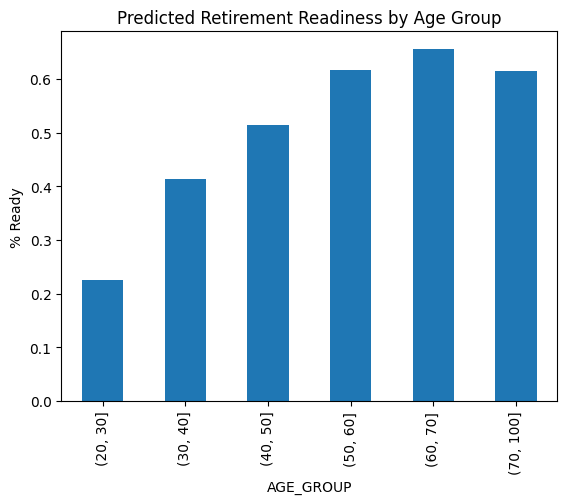

In [75]:
df_results.groupby('AGE_GROUP')['PREDICTED'].mean().plot(kind='bar')
plt.title('Predicted Retirement Readiness by Age Group')
plt.ylabel('% Ready')
plt.show()

In [77]:
for group in df['AGE_GROUP'].unique():
    subset = df[df['AGE_GROUP'] == group]
    
    if subset.shape[0] == 0:
        continue 
    
    X_sub = subset[features]
    y_sub = subset['LOG_RETQLIQ']
    
    model = LinearRegression().fit(X_sub, y_sub)
    
    print(group)
    print(pd.Series(model.coef_, index=features))

(60.0, 70.0]
LOG_EQUITY    0.678403
LOG_FIN       0.525262
LOG_LIQ      -0.242869
LOG_INCOME   -0.103633
LOG_DEBT      0.008460
LOG_STOCKS   -0.133820
EDUC          0.115177
FINLIT        0.149642
AGE          -0.056784
dtype: float64
(40.0, 50.0]
LOG_EQUITY    0.784436
LOG_FIN       0.564802
LOG_LIQ      -0.354140
LOG_INCOME   -0.004214
LOG_DEBT      0.020692
LOG_STOCKS   -0.148009
EDUC          0.000729
FINLIT        0.084367
AGE           0.010409
dtype: float64
(70.0, 100.0]
LOG_EQUITY    0.606046
LOG_FIN       0.567349
LOG_LIQ      -0.321022
LOG_INCOME   -0.060621
LOG_DEBT     -0.014441
LOG_STOCKS   -0.145636
EDUC          0.112498
FINLIT        0.459317
AGE          -0.096738
dtype: float64
(50.0, 60.0]
LOG_EQUITY    0.783438
LOG_FIN       0.409871
LOG_LIQ      -0.251762
LOG_INCOME   -0.002989
LOG_DEBT      0.039627
LOG_STOCKS   -0.140444
EDUC          0.035205
FINLIT       -0.017359
AGE          -0.027416
dtype: float64
(20.0, 30.0]
LOG_EQUITY    0.864943
LOG_FIN       0.268326
